In [ ]:
# imports

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [2]:
# import dataset

df = pd.read_csv("6 class csv.csv")

df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [3]:
# dataset overview
print("Shape:", df.shape)
print()
print(df.info())
print()
print(df.describe())

Shape: (240, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB
None

       Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  \
count       240.000000        240.000000    240.000000   
mean      10497.462500     107188.361635    237.157781   
std        9552.425037     179432.244940    517.155763   
min        1939.000000          0.000080      0.008400   
25%        3344.250000          0.000865   

In [4]:
# rename columns

df.columns = [
    "temperature",
    "luminosity",
    "radius",
    "absolute_magnitude",
    "star_color",
    "spectral_class",
    "star_type"
]

df.head()

,temperature,luminosity,radius,absolute_magnitude,star_color,spectral_class,star_type
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [5]:
# missing values:

print(df.isnull().sum())


temperature           0
luminosity            0
radius                0
absolute_magnitude    0
star_color            0
spectral_class        0
star_type             0
dtype: int64


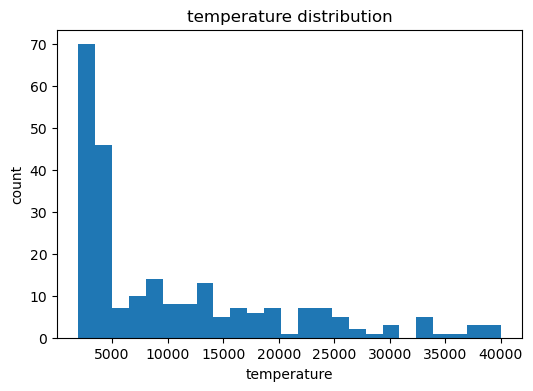

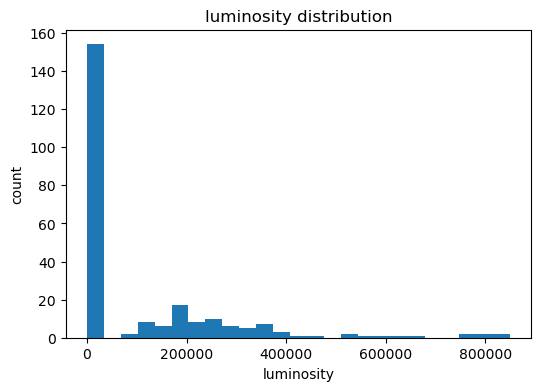

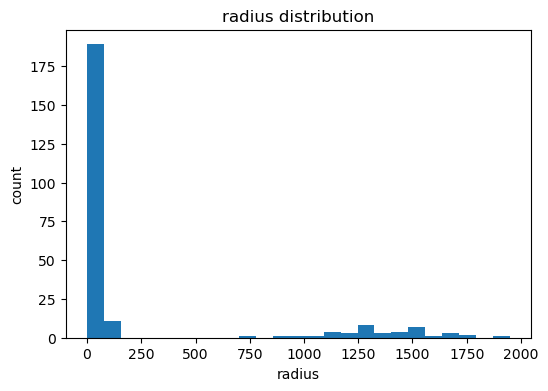

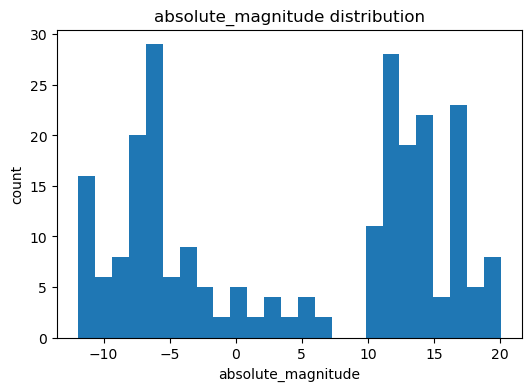

In [6]:
# feature distributions

num_cols = [
    "temperature",
    "luminosity",
    "radius",
    "absolute_magnitude"
]

for col in num_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=25)
    plt.title(f"{col} distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

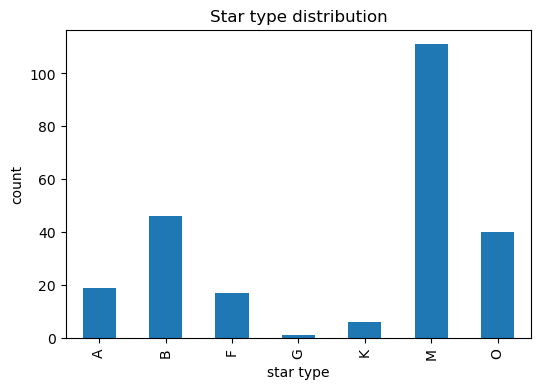

In [7]:
# label distribution

plt.figure(figsize=(6, 4))
df["star_type"].value_counts().sort_index().plot(kind="bar")
plt.title("Star type distribution")
plt.xlabel("star type")
plt.ylabel("count")
plt.show()

In [8]:
# encode ctegorical features

color_encoder = LabelEncoder()
spectral_encoder = LabelEncoder()

df["star_color"] = color_encoder.fit_transform(
    df["star_color"]
)

df["spectral_class"] = spectral_encoder.fit_transform(
    df["spectral_class"]
)

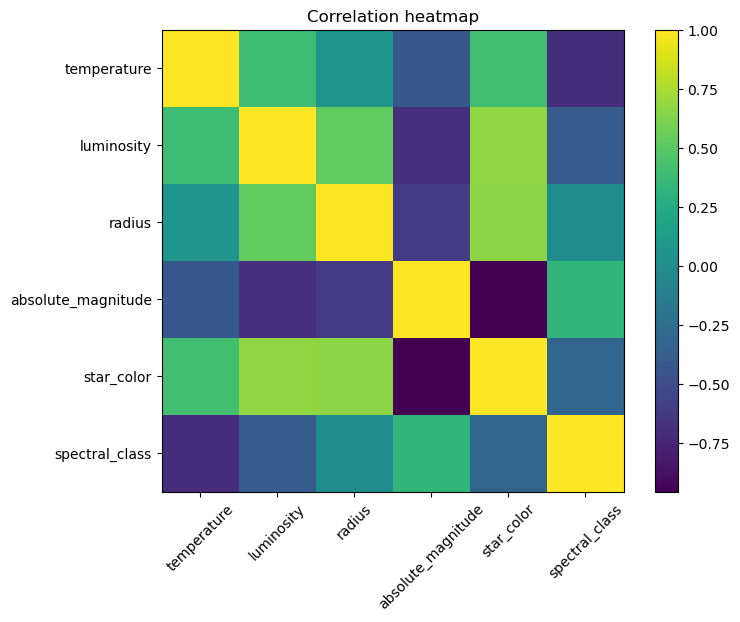

In [9]:
# correlation heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation heatmap")
plt.show()

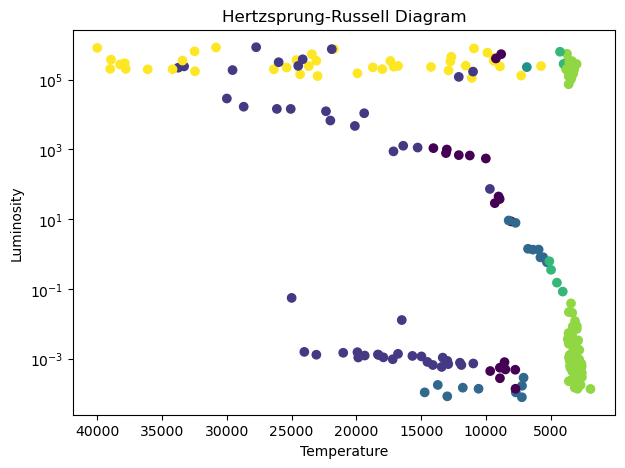

In [10]:
# HR diagram

plot_encoder = LabelEncoder()

plot_labels = plot_encoder.fit_transform(
    df["star_type"]
)

plt.figure(figsize=(7, 5))

plt.scatter(
    df["temperature"],
    df["luminosity"],
    c=plot_labels
)

plt.yscale("log")
plt.gca().invert_xaxis()

plt.xlabel("Temperature")
plt.ylabel("Luminosity")
plt.title("Hertzsprung-Russell Diagram")

plt.show()

In [11]:
# feature engineering - log transofrmation
# luminosity and radius are highly skewed

df["log_luminosity"] = np.log1p(df["luminosity"])
df["log_radius"] = np.log1p(df["radius"])

In [12]:
# features / target

df = pd.read_csv("6 class csv.csv")

target_col = "Star type"

X = df.drop(columns=[target_col])
y = df[target_col]

print(y.value_counts())

from sklearn.preprocessing import LabelEncoder

color_encoder = LabelEncoder()
spectral_encoder = LabelEncoder()

X["Star color"] = color_encoder.fit_transform(
    X["Star color"].str.strip()
)

X["Spectral Class"] = spectral_encoder.fit_transform(
    X["Spectral Class"].str.strip()
)

Star type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64


In [13]:
# train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

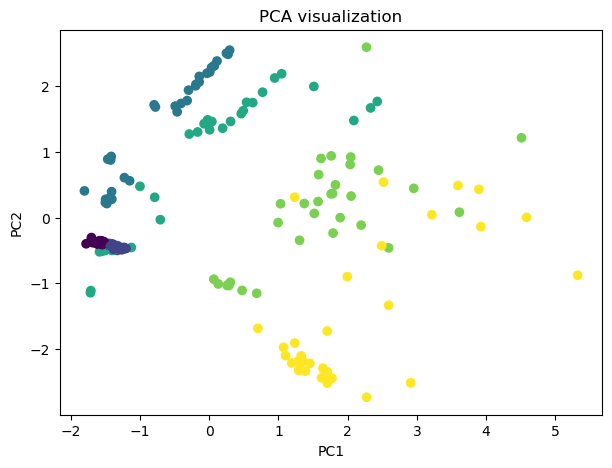

In [15]:
# PCA visualization

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_train
)

plt.title("PCA visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

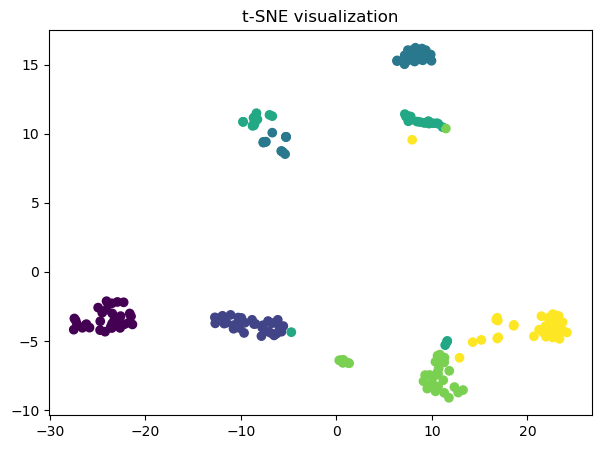

In [16]:
# t-sne visualization

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=20
)

X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_train
)

plt.title("t-SNE visualization")
plt.show()

In [17]:
# models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),
    "SVM": SVC(
        kernel="rbf",
        probability=True
    ),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(32,),
        max_iter=2000
    )
}

In [18]:
# cross validation

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5
    )

    print(name)
    print("CV accuracy:", scores.mean())
    print()

Logistic Regression
CV accuracy: 0.9634278002699055

SVM
CV accuracy: 0.9686909581646423

Decision Tree
CV accuracy: 0.9947368421052631

Random Forest
CV accuracy: 0.9948717948717949

MLP
CV accuracy: 0.9843454790823213



In [23]:
# hyperparemeter tuning - random forest

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None]
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    cv=5,
    scoring="accuracy"
)

rf_search.fit(X_train_scaled, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV score:", rf_search.best_score_)

# final model
rf = rf_search.best_estimator_

Best parameters: {'max_depth': 5, 'n_estimators': 50}
Best CV score: 1.0


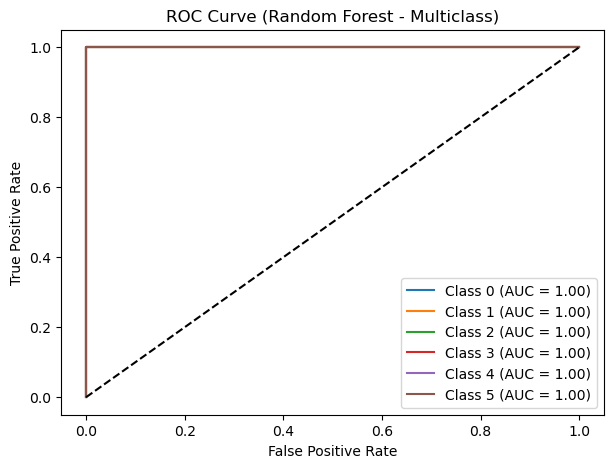

In [24]:
# roc curve + auc

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ensure correct class order
classes = rf.classes_

# binarize labels
y_bin = label_binarize(y_test, classes=classes)

# predicted probabilities
probs = rf.predict_proba(X_test_scaled)

plt.figure(figsize=(7,5))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

# diagonal reference line
plt.plot([0, 1], [0, 1], "k--")

plt.title("ROC Curve (Random Forest - Multiclass)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [26]:
# best model eval

best_rf = rf_search.best_estimator_

best_rf.fit(X_train_scaled, y_train)

pred = best_rf.predict(X_test_scaled)

In [27]:
# metrics

acc = accuracy_score(y_test, pred)
prec = precision_score(
    y_test,
    pred,
    average="weighted"
)
rec = recall_score(
    y_test,
    pred,
    average="weighted"
)
f1 = f1_score(
    y_test,
    pred,
    average="weighted"
)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


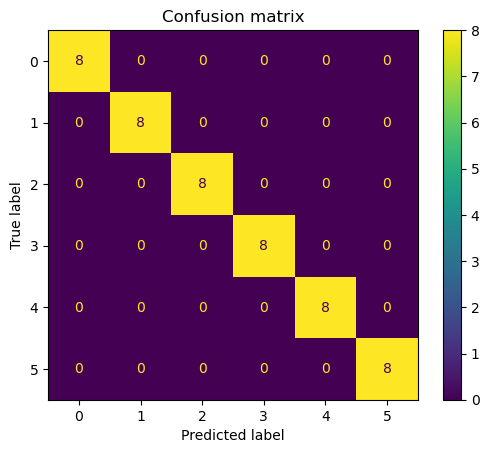

In [73]:
# confusion matrix

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.title("Confusion matrix")
plt.show()

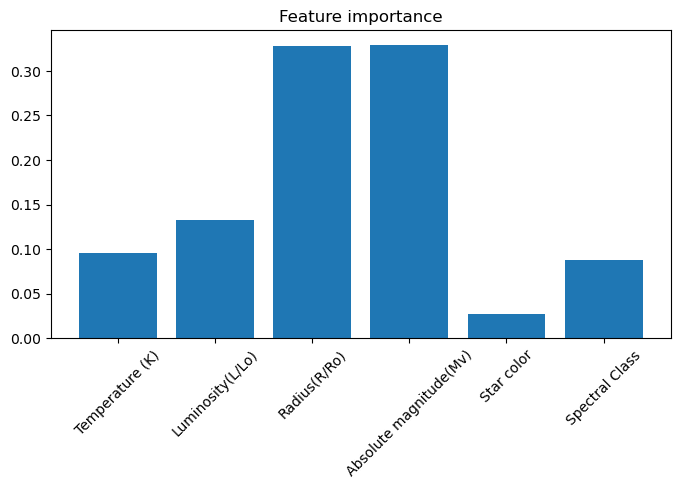

In [28]:
# feature importance

importances = best_rf.feature_importances_

plt.figure(figsize=(8, 4))

plt.bar(
    X.columns,
    importances
)

plt.xticks(rotation=45)
plt.title("Feature importance")
plt.show()

In [ ]:
# compare all models

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    results.append([
        name,
        accuracy_score(y_test, pred),
        f1_score(y_test, pred, average="weighted")
    ])

results_df = pd.DataFrame(
    results,
    columns=["model", "accuracy", "f1"]
)

print(results_df)

In [ ]:
# accuracy graph

plt.figure(figsize=(8, 4))

plt.bar(
    results_df["model"],
    results_df["accuracy"]
)

plt.xticks(rotation=20)
plt.title("Model comparison")
plt.ylabel("accuracy")
plt.show()